# 1. Аудит одномерного исследовательского ряда

**Цели:** проверить схему, пропуски, масштаб и визуально отделить центр распределения от редких событий. Данные фиксированы; истинных меток экстремумов нет.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/fractal_extreme_series.csv").exists())
DATA = ROOT / "data/fractal_extreme_series.csv"
SEED = 42
rng = np.random.default_rng(SEED)
df = pd.read_csv(DATA)
x = df["value"].to_numpy()
assert np.isfinite(x).all() and x.ndim == 1

summary = df.describe(percentiles=[.01,.05,.5,.95,.99]).T
summary


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,count,mean,std,min,1%,5%,50%,95%,99%,max
time,4096.0,2047.500000,1182.557680,0.000000,40.95000,204.750000,2047.50000,3890.250000,4054.05000,4095.000000
value,4096.0,0.009517,1.293205,-8.994277,-3.11659,-1.469981,-0.00047,1.588845,3.14066,10.617348


,count,mean,std,min,1%,5%,50%,95%,99%,max
time,4096.0,2047.500000,1182.557680,0.000000,40.95000,204.750000,2047.50000,3890.250000,4054.05000,4095.000000
value,4096.0,0.009517,1.293205,-8.994277,-3.11659,-1.469981,-0.00047,1.588845,3.14066,10.617348


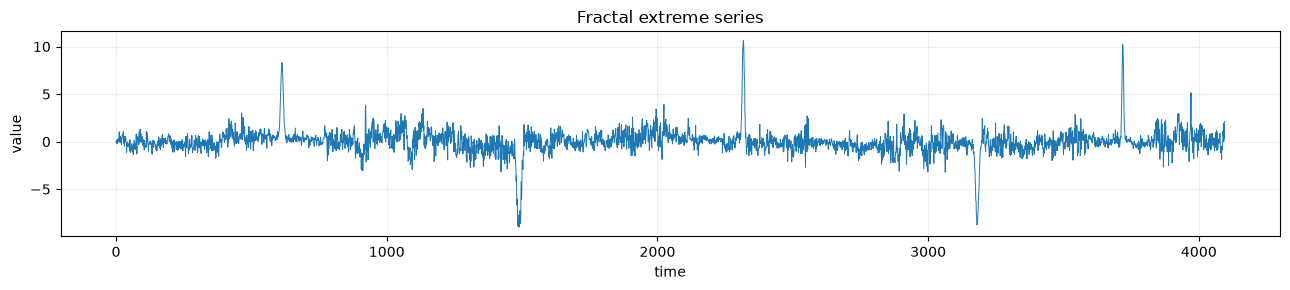

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df.time, x, lw=.7)
ax.set(title="Fractal extreme series", xlabel="time", ylabel="value")
ax.grid(alpha=.2); fig.tight_layout()
summary


Наблюдаемые пики — кандидаты, а не размеченная истина. Не выбирайте порог только по этой картинке.

**Самопроверка:** почему отсутствие пропусков не гарантирует качество? Что изменит стандартизация? Почему нельзя считать каждый высокий отсчёт независимым событием?